# UCI Student Performance Dataset - Exploratory Analysis

This notebook describes and explores the two UCI Student Performance datasets:
- **student-mat.csv** - Mathematics course
- **student-por.csv** - Portuguese language course

We'll examine:
1. Basic dataset info (shape, columns, types)
2. Statistical summaries
3. Missing values
4. Distribution of key features
5. Comparison between the two datasets

And finally I have combined the two datasets to generate one dataset since the columns are equal despite the course relavance

In [25]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Configure plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load the Datasets

In [26]:
# Load the datasets
math_df = pd.read_csv("/content/student-mat.csv", sep=';')
port_df = pd.read_csv("/content/student-por.csv", sep=';')

print("✓ Mathematics dataset loaded")
print("✓ Portuguese dataset loaded")

✓ Mathematics dataset loaded
✓ Portuguese dataset loaded


## 2. Basic Dataset Information

In [27]:
# Dataset shapes
print("="*70)
print("DATASET SHAPES")
print("="*70)
print(f"Mathematics dataset: {math_df.shape[0]} rows × {math_df.shape[1]} columns")
print(f"Portuguese dataset:  {port_df.shape[0]} rows × {port_df.shape[1]} columns")
print()

# Column names
print("="*70)
print("COLUMN NAMES")
print("="*70)
print(f"Total columns: {len(math_df.columns)}")
print(f"\nColumns:\n{list(math_df.columns)}")
print()

# Data types
print("="*70)
print("DATA TYPES - Mathematics")
print("="*70)
print(math_df.dtypes)
print()

print("="*70)
print("DATA TYPES - Portuguese")
print("="*70)
print(port_df.dtypes)

DATASET SHAPES
Mathematics dataset: 395 rows × 33 columns
Portuguese dataset:  649 rows × 33 columns

COLUMN NAMES
Total columns: 33

Columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

DATA TYPES - Mathematics
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64

In [28]:
# First few rows
print("="*70)
print("MATHEMATICS DATASET - First 5 Rows")
print("="*70)
display(math_df.head())
print()

print("="*70)
print("PORTUGUESE DATASET - First 5 Rows")
print("="*70)
display(port_df.head())

MATHEMATICS DATASET - First 5 Rows


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10



PORTUGUESE DATASET - First 5 Rows


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13


## 3. Checking for missing Values

In [29]:
# Check for missing values
print("="*70)
print("MISSING VALUES - Mathematics")
print("="*70)
math_missing = math_df.isnull().sum()
print(f"Total missing values: {math_missing.sum()}")
if math_missing.sum() > 0:
    print("\nMissing by column:")
    print(math_missing[math_missing > 0])
else:
    print("✓ No missing values found!")
print()

print("="*70)
print("MISSING VALUES - Portuguese")
print("="*70)
port_missing = port_df.isnull().sum()
print(f"Total missing values: {port_missing.sum()}")
if port_missing.sum() > 0:
    print("\nMissing by column:")
    print(port_missing[port_missing > 0])
else:
    print("✓ No missing values found!")

MISSING VALUES - Mathematics
Total missing values: 0
✓ No missing values found!

MISSING VALUES - Portuguese
Total missing values: 0
✓ No missing values found!


## 4. Statistical Summary

In [30]:
# Numeric columns summary
print("="*70)
print("MATHEMATICS DATASET - Numeric Summary")
print("="*70)
display(math_df.describe())
print()

print("="*70)
print("PORTUGUESE DATASET - Numeric Summary")
print("="*70)
display(port_df.describe())

MATHEMATICS DATASET - Numeric Summary


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000



PORTUGUESE DATASET - Numeric Summary


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [31]:
# Categorical columns summary
print("="*70)
print("CATEGORICAL FEATURES SUMMARY")
print("="*70)

# Get object/categorical columns
cat_cols = math_df.select_dtypes(include=['object']).columns

for col in cat_cols:
    print(f"\n{col.upper()}")
    print("-" * 50)
    print("Mathematics:")
    print(math_df[col].value_counts())
    print("\nPortuguese:")
    print(port_df[col].value_counts())
    print()

CATEGORICAL FEATURES SUMMARY

SCHOOL
--------------------------------------------------
Mathematics:
school
GP    349
MS     46
Name: count, dtype: int64

Portuguese:
school
GP    423
MS    226
Name: count, dtype: int64


SEX
--------------------------------------------------
Mathematics:
sex
F    208
M    187
Name: count, dtype: int64

Portuguese:
sex
F    383
M    266
Name: count, dtype: int64


ADDRESS
--------------------------------------------------
Mathematics:
address
U    307
R     88
Name: count, dtype: int64

Portuguese:
address
U    452
R    197
Name: count, dtype: int64


FAMSIZE
--------------------------------------------------
Mathematics:
famsize
GT3    281
LE3    114
Name: count, dtype: int64

Portuguese:
famsize
GT3    457
LE3    192
Name: count, dtype: int64


PSTATUS
--------------------------------------------------
Mathematics:
Pstatus
T    354
A     41
Name: count, dtype: int64

Portuguese:
Pstatus
T    569
A     80
Name: count, dtype: int64


MJOB
-------------

GRADE STATISTICS

Mathematics:
               G1          G2          G3
count  395.000000  395.000000  395.000000
mean    10.908861   10.713924   10.415190
std      3.319195    3.761505    4.581443
min      3.000000    0.000000    0.000000
25%      8.000000    9.000000    8.000000
50%     11.000000   11.000000   11.000000
75%     13.000000   13.000000   14.000000
max     19.000000   19.000000   20.000000

Portuguese:
               G1          G2          G3
count  649.000000  649.000000  649.000000
mean    11.399076   11.570108   11.906009
std      2.745265    2.913639    3.230656
min      0.000000    0.000000    0.000000
25%     10.000000   10.000000   10.000000
50%     11.000000   11.000000   12.000000
75%     13.000000   13.000000   14.000000
max     19.000000   19.000000   19.000000


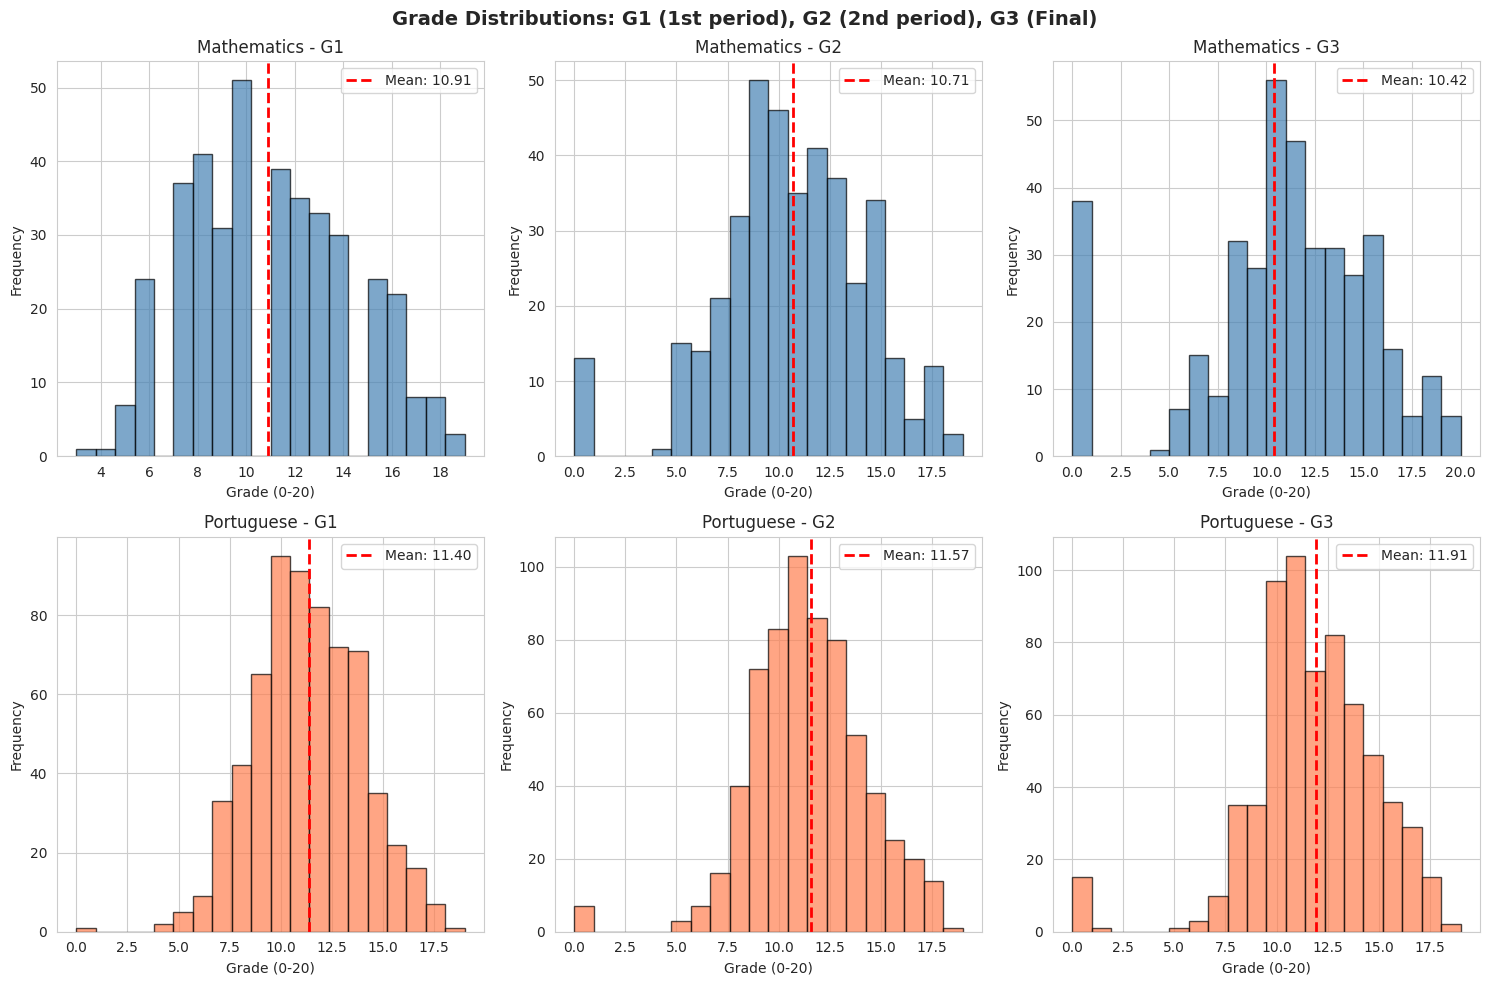

In [32]:
# Grade distributions (G1, G2, G3)
print("="*70)
print("GRADE STATISTICS")
print("="*70)
print("\nMathematics:")
print(math_df[['G1', 'G2', 'G3']].describe())
print("\nPortuguese:")
print(port_df[['G1', 'G2', 'G3']].describe())

# Visualize grade distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Grade Distributions: G1 (1st period), G2 (2nd period), G3 (Final)', fontsize=14, fontweight='bold')

# Mathematics grades
for i, grade in enumerate(['G1', 'G2', 'G3']):
    axes[0, i].hist(math_df[grade], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, i].set_title(f'Mathematics - {grade}')
    axes[0, i].set_xlabel('Grade (0-20)')
    axes[0, i].set_ylabel('Frequency')
    axes[0, i].axvline(math_df[grade].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {math_df[grade].mean():.2f}')
    axes[0, i].legend()

# Portuguese grades
for i, grade in enumerate(['G1', 'G2', 'G3']):
    axes[1, i].hist(port_df[grade], bins=20, color='coral', edgecolor='black', alpha=0.7)
    axes[1, i].set_title(f'Portuguese - {grade}')
    axes[1, i].set_xlabel('Grade (0-20)')
    axes[1, i].set_ylabel('Frequency')
    axes[1, i].axvline(port_df[grade].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {port_df[grade].mean():.2f}')
    axes[1, i].legend()

plt.tight_layout()
plt.show()

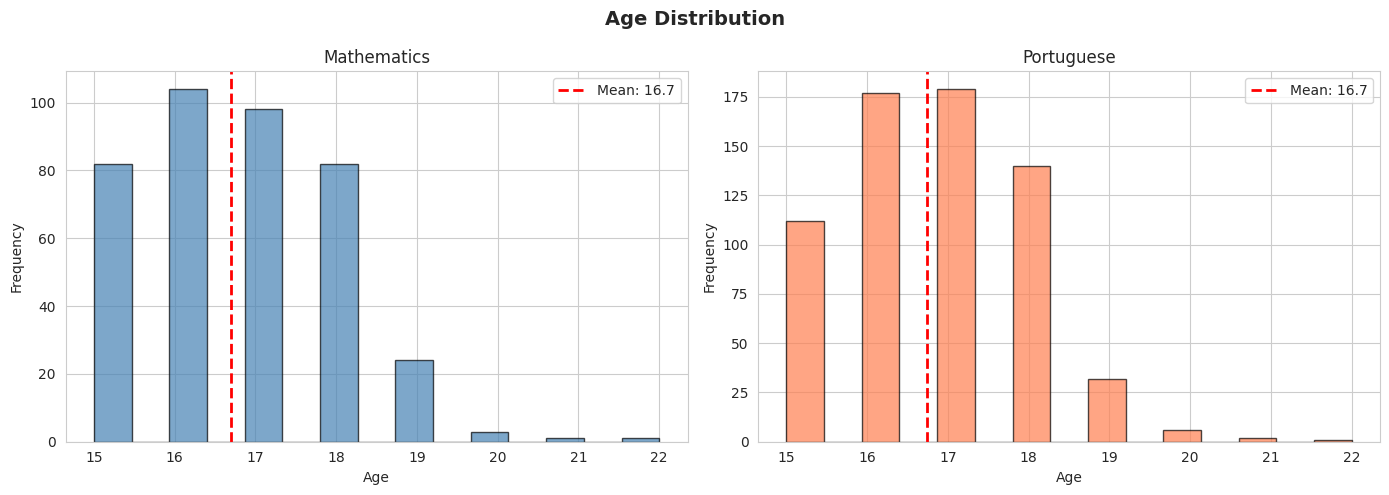

In [33]:
# Age distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Age Distribution', fontsize=14, fontweight='bold')

axes[0].hist(math_df['age'], bins=15, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Mathematics')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].axvline(math_df['age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {math_df["age"].mean():.1f}')
axes[0].legend()

axes[1].hist(port_df['age'], bins=15, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Portuguese')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')
axes[1].axvline(port_df['age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {port_df["age"].mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

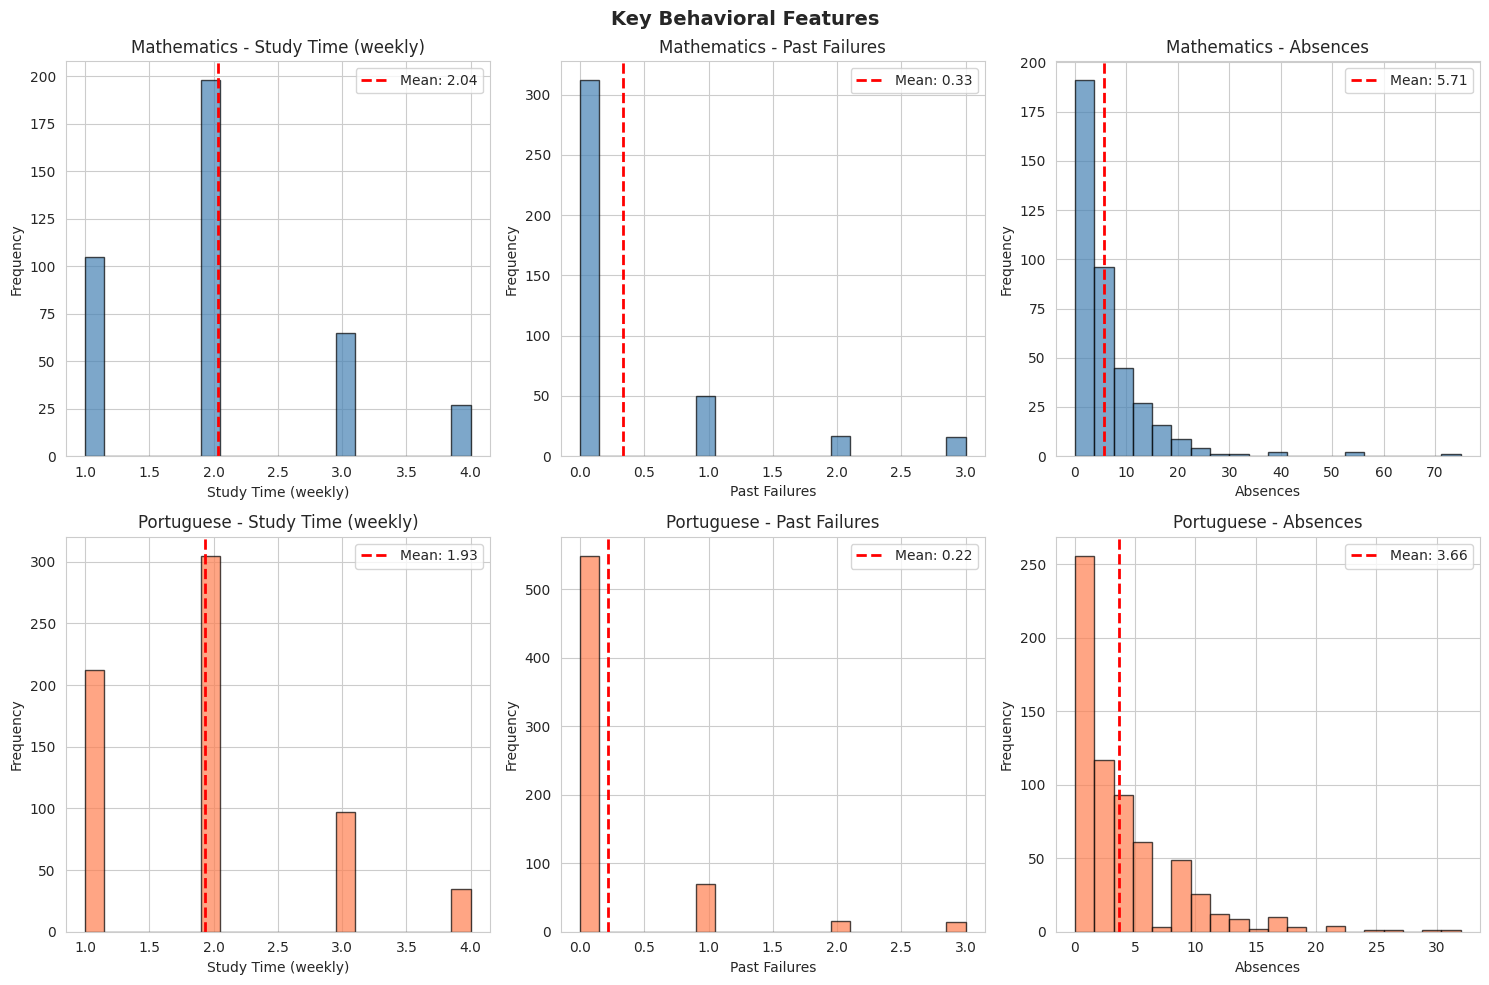

In [34]:
# Study time, failures, absences
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Key Behavioral Features', fontsize=14, fontweight='bold')

features = ['studytime', 'failures', 'absences']
titles = ['Study Time (weekly)', 'Past Failures', 'Absences']
colors = ['steelblue', 'coral']
datasets = [('Mathematics', math_df), ('Portuguese', port_df)]

for row, (dataset_name, df) in enumerate(datasets):
    for col, (feature, title) in enumerate(zip(features, titles)):
        axes[row, col].hist(df[feature], bins=20, color=colors[row], edgecolor='black', alpha=0.7)
        axes[row, col].set_title(f'{dataset_name} - {title}')
        axes[row, col].set_xlabel(title)
        axes[row, col].set_ylabel('Frequency')
        axes[row, col].axvline(df[feature].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[feature].mean():.2f}')
        axes[row, col].legend()

plt.tight_layout()
plt.show()

In [35]:
# Create comparison table
comparison_data = {
    'Metric': [
        'Total Students',
        'Number of Features',
        'Missing Values',
        'Average Age',
        'Average Final Grade (G3)',
        'Students with Failures',
        'Average Study Time',
        'Average Absences'
    ],
    'Mathematics': [
        math_df.shape[0],
        math_df.shape[1],
        math_df.isnull().sum().sum(),
        f"{math_df['age'].mean():.2f}",
        f"{math_df['G3'].mean():.2f}",
        f"{(math_df['failures'] > 0).sum()} ({(math_df['failures'] > 0).sum() / len(math_df) * 100:.1f}%)",
        f"{math_df['studytime'].mean():.2f}",
        f"{math_df['absences'].mean():.2f}"
    ],
    'Portuguese': [
        port_df.shape[0],
        port_df.shape[1],
        port_df.isnull().sum().sum(),
        f"{port_df['age'].mean():.2f}",
        f"{port_df['G3'].mean():.2f}",
        f"{(port_df['failures'] > 0).sum()} ({(port_df['failures'] > 0).sum() / len(port_df) * 100:.1f}%)",
        f"{port_df['studytime'].mean():.2f}",
        f"{port_df['absences'].mean():.2f}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("="*70)
print("DATASET COMPARISON")
print("="*70)
display(comparison_df)

DATASET COMPARISON


,Metric,Mathematics,Portuguese
0,Total Students,395,649
1,Number of Features,33,33
2,Missing Values,0,0
3,Average Age,16.70,16.74
4,Average Final Grade (G3),10.42,11.91
5,Students with Failures,83 (21.0%),100 (15.4%)
6,Average Study Time,2.04,1.93
7,Average Absences,5.71,3.66


In [36]:
# Verify columns are identical
print("="*70)
print("COLUMN VERIFICATION")
print("="*70)
print(f"Mathematics columns: {len(math_df.columns)}")
print(f"Portuguese columns: {len(port_df.columns)}")
print(f"Columns match: {list(math_df.columns) == list(port_df.columns)}")
print()

# Add course identifier to each dataset
math_df_copy = math_df.copy()
port_df_copy = port_df.copy()

math_df_copy['course'] = 'Mathematics'
port_df_copy['course'] = 'Portuguese'

# Combine datasets
combined_df = pd.concat([math_df_copy, port_df_copy], ignore_index=True)

print("="*70)
print("COMBINED DATASET CREATED")
print("="*70)
print(f"Total students: {combined_df.shape[0]}")
print(f"Total features: {combined_df.shape[1]}")
print(f"Mathematics students: {(combined_df['course'] == 'Mathematics').sum()}")
print(f"Portuguese students: {(combined_df['course'] == 'Portuguese').sum()}")
print()

# Display first few rows
print("First 5 rows of combined dataset:")
display(combined_df.head())

COLUMN VERIFICATION
Mathematics columns: 33
Portuguese columns: 33
Columns match: True

COMBINED DATASET CREATED
Total students: 1044
Total features: 34
Mathematics students: 395
Portuguese students: 649

First 5 rows of combined dataset:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,course
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6,Mathematics
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6,Mathematics
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10,Mathematics
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15,Mathematics
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10,Mathematics


COMBINED DATASET - STATISTICAL SUMMARY


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000
mean,16.726054,2.603448,2.387931,1.522989,1.970307,0.264368,3.935824,3.201149,3.156130,1.494253,2.284483,3.543103,4.434866,11.213602,11.246169,11.341954
std,1.239975,1.124907,1.099938,0.731727,0.834353,0.656142,0.933401,1.031507,1.152575,0.911714,1.285105,1.424703,6.210017,2.983394,3.285071,3.864796
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,9.000000,9.000000,10.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000



COURSE DISTRIBUTION
course
Portuguese     649
Mathematics    395
Name: count, dtype: int64



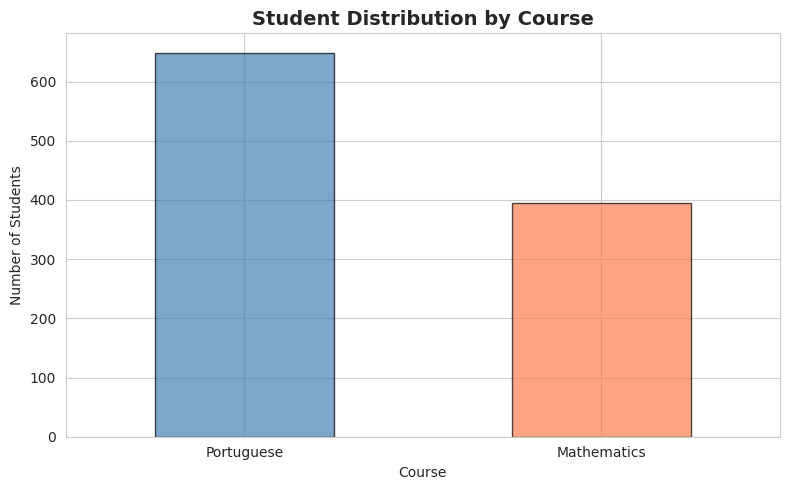

In [37]:
# Summary statistics of combined dataset
print("="*70)
print("COMBINED DATASET - STATISTICAL SUMMARY")
print("="*70)
display(combined_df.describe())
print()

# Check course distribution
print("="*70)
print("COURSE DISTRIBUTION")
print("="*70)
course_dist = combined_df['course'].value_counts()
print(course_dist)
print()

# Visualize course distribution
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
course_dist.plot(kind='bar', color=['steelblue', 'coral'], ax=ax, alpha=0.7, edgecolor='black')
ax.set_title('Student Distribution by Course', fontsize=14, fontweight='bold')
ax.set_xlabel('Course')
ax.set_ylabel('Number of Students')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

GRADE COMPARISON BY COURSE (Combined Dataset)


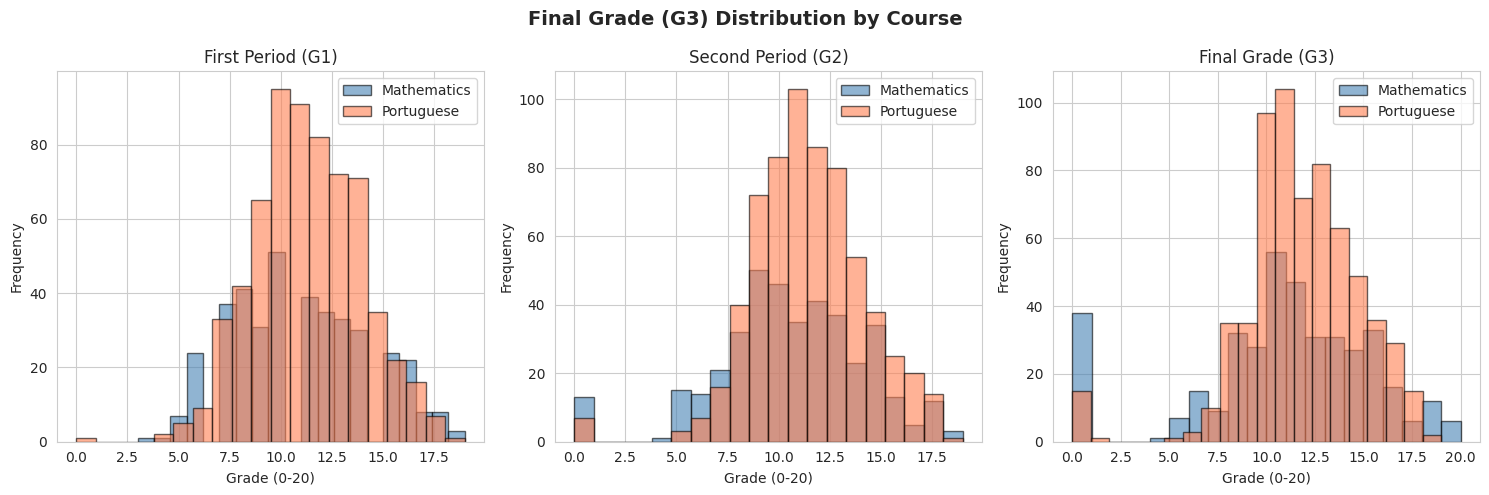


Grade Statistics by Course:
                G1                                                       G2  \
             count       mean       std  min   25%   50%   75%   max  count   
course                                                                        
Mathematics  395.0  10.908861  3.319195  3.0   8.0  11.0  13.0  19.0  395.0   
Portuguese   649.0  11.399076  2.745265  0.0  10.0  11.0  13.0  19.0  649.0   

                                                                  G3  \
                  mean       std  min   25%   50%   75%   max  count   
course                                                                 
Mathematics  10.713924  3.761505  0.0   9.0  11.0  13.0  19.0  395.0   
Portuguese   11.570108  2.913639  0.0  10.0  11.0  13.0  19.0  649.0   

                                                               
                  mean       std  min   25%   50%   75%   max  
course                                                         
Mathematics  10.415190

In [38]:
# Compare grades between courses in combined dataset
print("="*70)
print("GRADE COMPARISON BY COURSE (Combined Dataset)")
print("="*70)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Final Grade (G3) Distribution by Course', fontsize=14, fontweight='bold')

grades = ['G1', 'G2', 'G3']
titles = ['First Period (G1)', 'Second Period (G2)', 'Final Grade (G3)']

for idx, (grade, title) in enumerate(zip(grades, titles)):
    combined_df[combined_df['course'] == 'Mathematics'][grade].hist(
        bins=20, alpha=0.6, label='Mathematics', color='steelblue', ax=axes[idx], edgecolor='black'
    )
    combined_df[combined_df['course'] == 'Portuguese'][grade].hist(
        bins=20, alpha=0.6, label='Portuguese', color='coral', ax=axes[idx], edgecolor='black'
    )
    axes[idx].set_title(title)
    axes[idx].set_xlabel('Grade (0-20)')
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()

plt.tight_layout()
plt.show()

# Statistical comparison
print("\nGrade Statistics by Course:")
print(combined_df.groupby('course')[['G1', 'G2', 'G3']].describe())

In [39]:

# Save combined dataset
output_file =  "uci_combined_students.csv"
combined_df.to_csv(output_file, index=False)

print("="*70)
print("COMBINED DATASET SAVED")
print("="*70)
print(f"File saved to: {output_file}")
print(f"Total records: {len(combined_df)}")
print(f"Total features: {len(combined_df.columns)}")
print()

# Also save individual processed datasets with course indicator
math_output = "uci_math_students.csv"
port_output = "uci_portuguese_students.csv"

math_df_copy.to_csv(math_output, index=False)
port_df_copy.to_csv(port_output, index=False)

print(f"✓ Mathematics dataset saved to: {math_output}")
print(f"✓ Portuguese dataset saved to: {port_output}")
print(f"✓ Combined dataset saved to: {output_file}")
print()
print("All datasets are ready for further analysis and modeling!")

COMBINED DATASET SAVED
File saved to: uci_combined_students.csv
Total records: 1044
Total features: 34

✓ Mathematics dataset saved to: uci_math_students.csv
✓ Portuguese dataset saved to: uci_portuguese_students.csv
✓ Combined dataset saved to: uci_combined_students.csv

All datasets are ready for further analysis and modeling!


In [40]:
cdf = pd.read_csv("/content/uci_combined_students.csv")
cdf.head(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,course
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6,Mathematics
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6,Mathematics
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10,Mathematics
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15,Mathematics
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10,Mathematics
